# Plotting trend lines in Python

Trend lines are the support and resistance lines traders draw on price charts: a line under the rising swing lows, or over the falling swing highs. Drawn by hand they take seconds — drawing them *programmatically* is surprisingly tricky, which is why most Python charting examples stop at moving averages.

The catch is that a trend line is not a regression. A fitted line runs through the middle of the data; a trend line *bounds* it — anchored at swing points, touched from one side, and never cut through. An algorithm has to decide what counts as a swing, which pair of swings anchors the line, and which of many candidate lines is the one a human would draw.

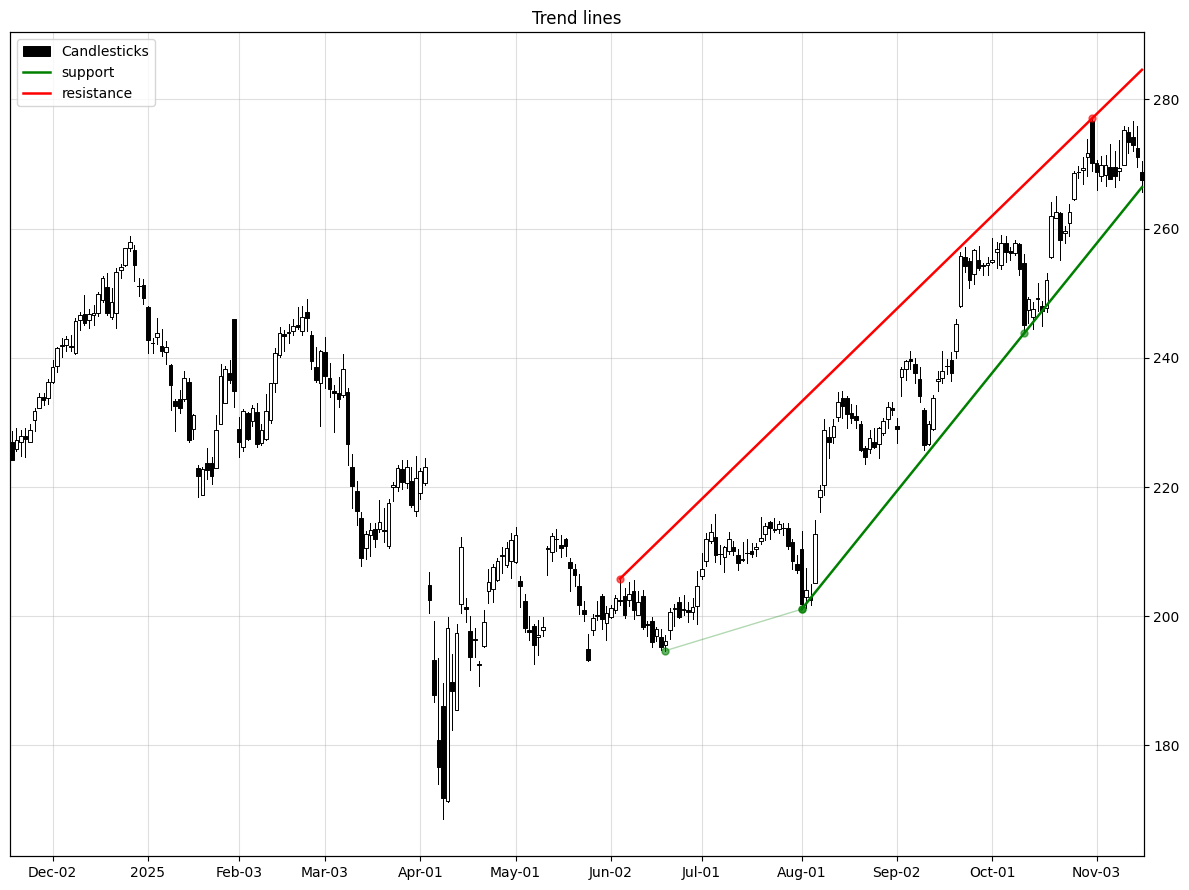

In [1]:
from mplchart.chart import Chart
from mplchart.primitives import Candlesticks, TrendLines
from mplchart.samples import sample_prices

prices = sample_prices()

Chart(prices, title="Trend lines", max_bars=250).plot(
    Candlesticks(),
    TrendLines(span=5),
).show()

mplchart ships this as the `TrendLines` primitive (experimental — the API is likely to change). It walks backward from the most recent bar, building a *ladder* of candidate legs on each side: support fitted to the lows (green), resistance to the highs (red). The winning leg on each side extends to the present with its touch points marked; runner-up legs are drawn faded, stopping where they were overtaken.

The main knob is `span`, the swing filter: a bar only qualifies as a touch point if it is an extreme within ± `span` bars. Small values track short-term structure; larger values anchor only at major swings.

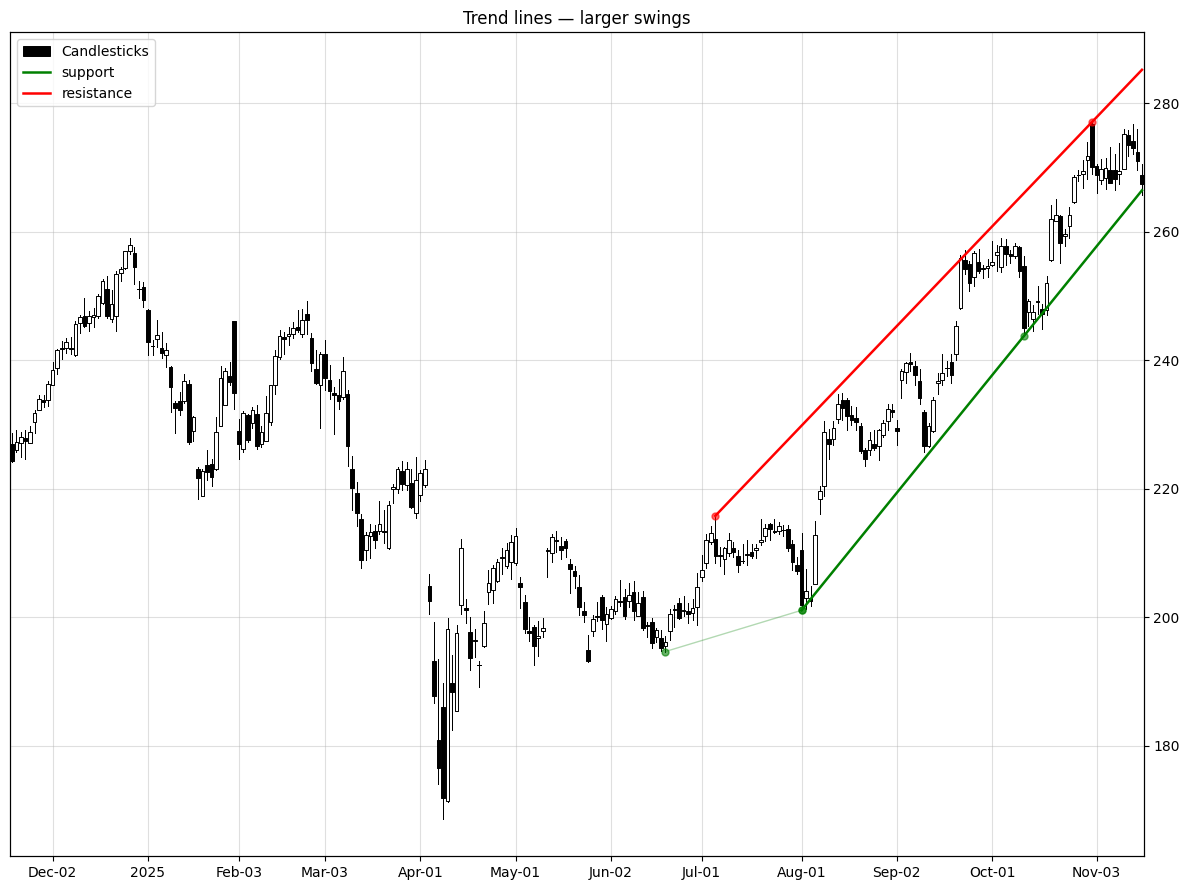

In [2]:
Chart(prices, title="Trend lines — larger swings", max_bars=250).plot(
    Candlesticks(),
    TrendLines(span=10),
).show()

Further knobs follow a zero-disables convention: `max_gap` bounds how far back the walk may bridge across structure (in units of the average bar move) before treating it as a different price regime, `max_bars` is a time safety net, and `max_legs` caps the ladder depth. `colors` sets the (support, resistance) pair.

Since `TrendLines` is a regular primitive, it composes with everything else — indicators, panes, volume — and works on pandas and polars data alike. See the primitives tutorial for how primitives fit together, and the Gallery for more chart examples.